In [5]:
# 必要なライブラリをインポート
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 日本語表示のための設定 (japanize_matplotlib)
import japanize_matplotlib

# --- 1. データの読み込み ---
# クレンジング済みのデータを読み込む
cleaned_data_path = '../data/processed/cleaned_data.parquet'
df = pd.read_parquet(cleaned_data_path)


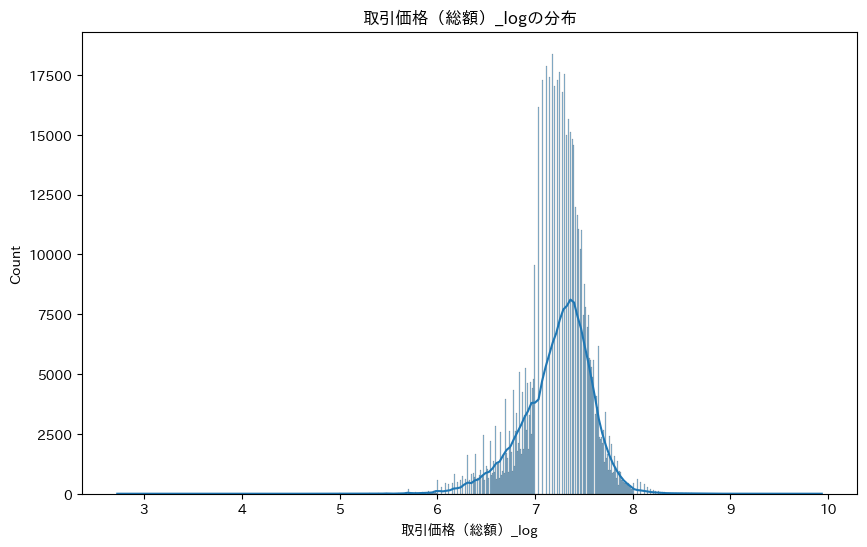

In [6]:
# --- 2. データの可視化と分析 ---
# 例：価格の分布をヒストグラムで確認
plt.figure(figsize=(10, 6))
sns.histplot(df['取引価格（総額）_log'], kde=True)
plt.title('取引価格（総額）_logの分布')
plt.show()


都道府県ごとのデータ件数
三重県: 1,576件
京都府: 13,925件
佐賀県: 448件
兵庫県: 34,249件
北海道: 17,997件
千葉県: 29,705件
和歌山県: 571件
埼玉県: 34,900件
大分県: 1,921件
大阪府: 66,906件
奈良県: 4,579件
宮城県: 8,652件
宮崎県: 924件
富山県: 791件
山口県: 1,561件
山形県: 373件
山梨県: 424件
岐阜県: 862件
岡山県: 1,909件
岩手県: 1,022件
島根県: 189件
広島県: 3,646件
徳島県: 413件
愛媛県: 1,655件
愛知県: 27,295件
新潟県: 2,647件
東京都: 178,171件
栃木県: 1,579件
沖縄県: 949件
滋賀県: 2,629件
熊本県: 1,567件
石川県: 845件
神奈川県: 77,614件
福井県: 379件
福岡県: 25,808件
福島県: 1,264件
秋田県: 546件
群馬県: 1,504件
茨城県: 2,715件
長崎県: 756件
長野県: 993件
青森県: 567件
静岡県: 3,952件
香川県: 1,637件
高知県: 274件
鳥取県: 405件
鹿児島県: 1,219件
合計: 564,513件


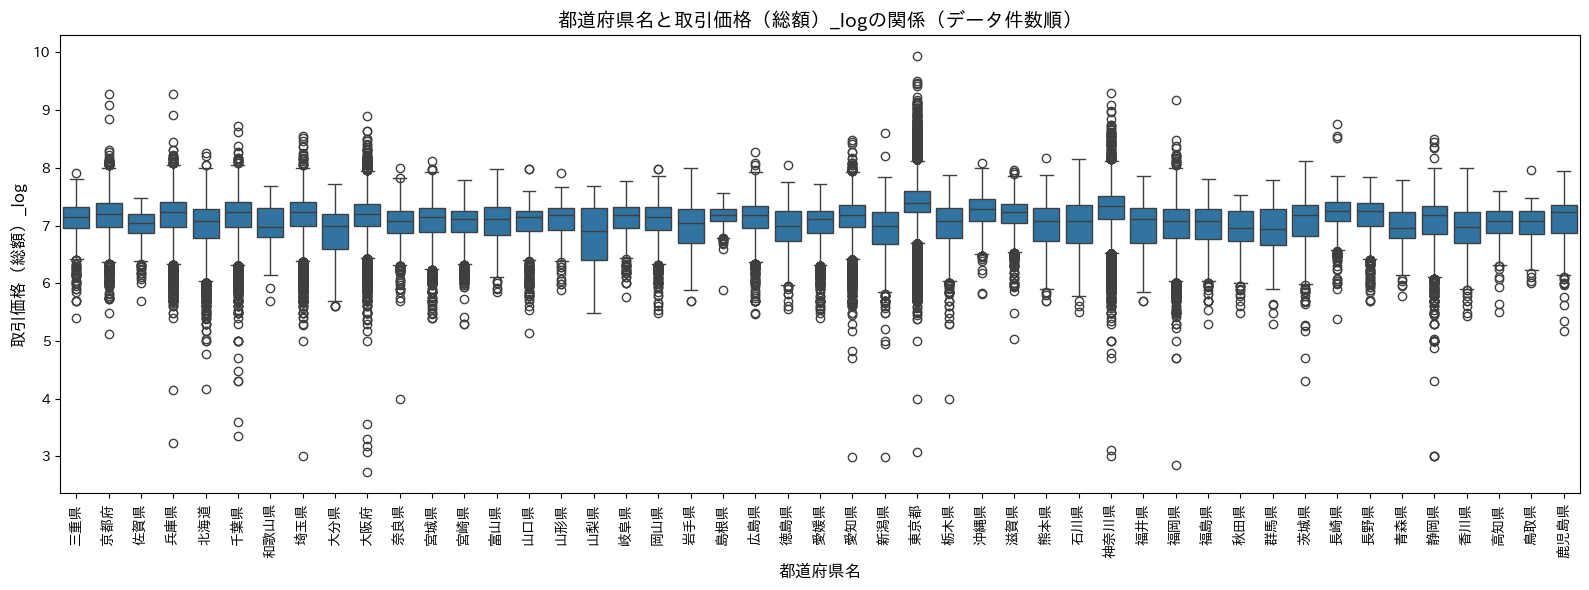


都道府県ごとの価格統計
        count      mean       std       min       max
都道府県名                                                
東京都    178171  7.395189  0.305636  3.079181  9.934498
神奈川県    77614  7.279760  0.332491  3.000000  9.301030
大阪府     66906  7.179283  0.295328  2.724276  8.892095
埼玉県     34900  7.190188  0.317067  3.000000  8.544068
兵庫県     34249  7.185616  0.319141  3.230449  9.278754
千葉県     29705  7.169982  0.329589  3.361728  8.724276
愛知県     27295  7.131400  0.320734  2.991226  8.477121
福岡県     25808  7.012804  0.365673  2.845098  9.176091
北海道     17997  6.994877  0.369029  4.176091  8.255273
京都府     13925  7.175404  0.316491  5.113943  9.278754
宮城県      8652  7.073519  0.331146  5.397940  8.113943
奈良県      4579  7.065763  0.284399  4.000000  7.991226
静岡県      3952  7.056753  0.431511  3.000000  8.505150
広島県      3646  7.109277  0.331036  5.462398  8.278754
茨城県      2715  7.061840  0.384405  4.301030  8.113943
新潟県      2647  6.937792  0.402567  2.991226  8.602060
滋賀県      2629  

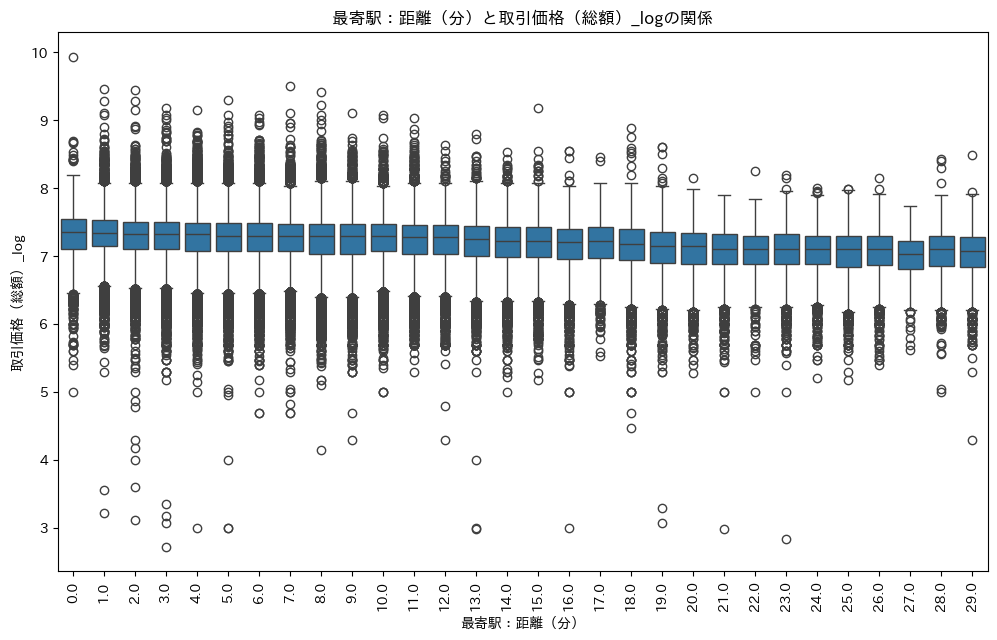

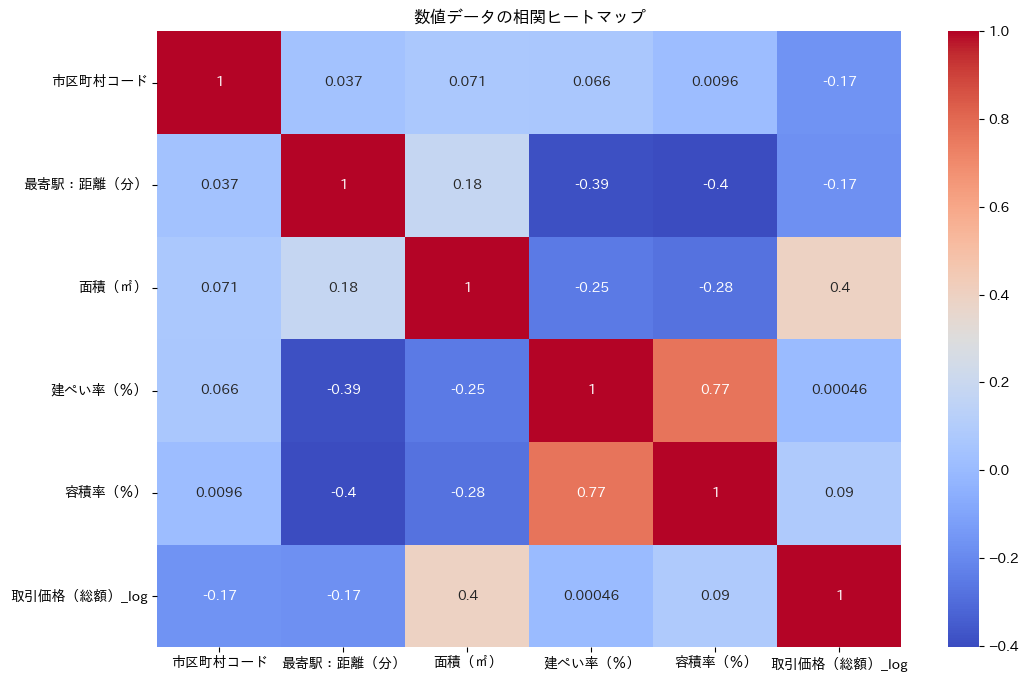

In [7]:


# データ件数を集計
prefecture_counts = df['都道府県名'].value_counts().sort_index()

print("=" * 60)
print("都道府県ごとのデータ件数")
print("=" * 60)
for pref, count in prefecture_counts.items():
    print(f"{pref}: {count:,}件")
print("=" * 60)
print(f"合計: {prefecture_counts.sum():,}件")
print("=" * 60)

# 箱ひげ図（データ件数順にソート）
plt.figure(figsize=(16, 6))
order = prefecture_counts.index  # データ件数でソート
sns.boxplot(x='都道府県名', y='取引価格（総額）_log', data=df, order=order)
plt.title('都道府県名と取引価格（総額）_logの関係（データ件数順）', fontsize=14)
plt.xlabel('都道府県名', fontsize=12)
plt.ylabel('取引価格（総額）_log', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 基本統計量も出力
print("\n都道府県ごとの価格統計")
print("=" * 80)
stats = df.groupby('都道府県名')['取引価格（総額）_log'].agg(['count', 'mean', 'std', 'min', 'max'])
stats = stats.sort_values('count', ascending=False)
print(stats.to_string())
# 例：築年数と価格の関係を箱ひげ図で確認
plt.figure(figsize=(12, 7))
sns.boxplot(x='最寄駅：距離（分）', y='取引価格（総額）_log', data=df)
plt.title('最寄駅：距離（分）と取引価格（総額）_logの関係')
plt.xticks(rotation=90)
plt.show()

# 例：数値データ間の相関をヒートマップで確認
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('数値データの相関ヒートマップ')
plt.show()

In [3]:
df.columns

Index(['都道府県名', '市区町村名', '地区名', '最寄駅：名称', '最寄駅：距離（分）', '間取り', '面積（㎡）', '建築年',
       '建物の構造', '用途', '今後の利用目的', '都市計画', '建ぺい率（％）', '容積率（％）', '取引時点', '改装',
       '取引の事情等', '取引価格（総額）_log'],
      dtype='object')

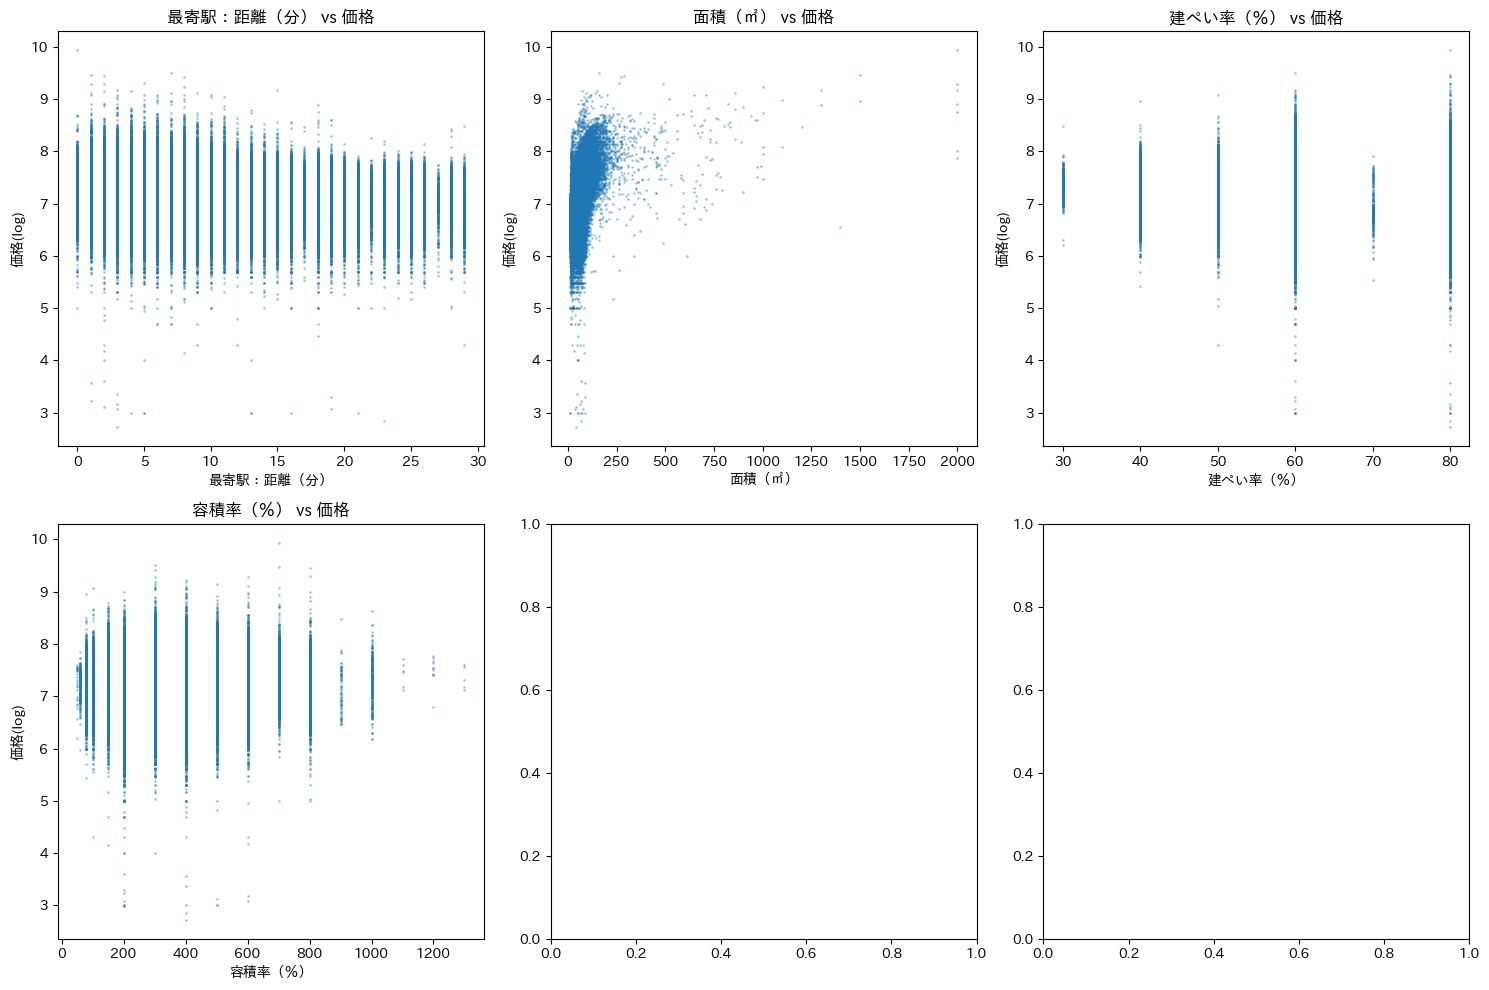

In [8]:
# 重要な特徴量との相関


important_features = ['最寄駅：距離（分）',
       '面積（㎡）','建ぺい率（％）',
       '容積率（％）']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, col in enumerate(important_features):
    ax = axes[i//3, i%3]
    ax.scatter(df[col], df['取引価格（総額）_log'], alpha=0.3, s=1)
    ax.set_xlabel(col)
    ax.set_ylabel('価格(log)')
    ax.set_title(f'{col} vs 価格')
plt.tight_layout()
plt.show()